# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean()) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

En los valores nulos observamos en cada uno de los dataset lo siguiente:

Dataset users

city

Valores nulos: 469
Proporción: 11.73%
Acción recomendada: Investigar e imputar si es posible; en caso contrario, mantener los nulos o crear una categoría "Unknown".
Justificación: La proporción se encuentra entre 5% y 30%, por lo que puede afectar análisis por ciudad y conviene analizarla antes de eliminar registros.

churn_date

Valores nulos: 3534
Proporción: 88.35%
Acción recomendada: Mantener la columna e interpretar los nulos como clientes que no han cancelado el servicio.
Justificación: Aunque supera el 80%, los valores nulos parecen tener significado de negocio y no representan datos faltantes reales.
Dataset usage

date

Valores nulos: 50
Proporción: 0.125%
Acción recomendada: Imputar si es posible o eliminar esos registros.
Justificación: La proporción es muy baja (<5%) y su impacto sobre el análisis será mínimo.

duration

Valores nulos: 22,076
Proporción: 55.19%
Acción recomendada: Investigar la relación con la variable type antes de imputar o eliminar.
Justificación: El porcentaje es elevado y podría deberse a que ciertos tipos de eventos (por ejemplo, mensajes) no requieren duración.

length

Valores nulos: 17,896
Proporción: 44.74%
Acción recomendada: Investigar la relación con la variable type.
Justificación: Es probable que esta variable solo aplique a determinados tipos de uso, por lo que los nulos podrían ser esperados y no errores de calidad.

Conclusión general

Los valores nulos más relevantes se encuentran en las columnas city, duration y length. En particular, los nulos de duration y length requieren una revisión conjunta con la variable type, ya que probablemente correspondan a diferentes tipos de servicio (llamadas o mensajes) y podrían representar ausencia válida de información en lugar de datos faltantes. Por su parte, los nulos de churn_date parecen tener un significado de negocio asociado a clientes activos, por lo que no deberían tratarse como un problema de calidad de datos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: No presenta valores inválidos. Los identificadores se encuentran en un rango coherente (10000-13999) y corresponden a una variable de identificación, por lo que no requiere tratamiento adicional.
  
  -La columna contiene 4.000 registros únicos identificados entre 10000 y 13999.

  -La media es 11.999,5, coincidiendo con la mediana (11.999,5), lo que indica que los identificadores están distribuidos de forma secuencial.

  - No se observan valores negativos ni anómalos.

Conclusión: No se identifican sentinels ni problemas de calidad en esta variable. Además, al tratarse de un identificador, no es una variable útil para el análisis estadístico del comportamiento de los clientes.

- La columna `age`: Se detectó un valor mínimo de -999 años, imposible en términos reales y probablemente utilizado como valor sentinel para indicar un dato faltante. Este valor afecta la media y la desviación estándar de la variable, por lo que se recomienda reemplazarlo por NaN antes de continuar con el análisis.
      - La edad promedio es 33,74 años.
      - El rango intercuartílico muestra que el 50 % de los usuarios tiene entre 32 y 63 años.
      - La edad máxima es 79 años, un valor razonable.
      - La edad mínima es -999 años, un valor imposible para una persona.
      - La presencia de -999 sugiere un valor sentinel utilizado para representar información faltante o desconocida.
      - La desviación estándar (123,23) es excesivamente alta para una variable de edad, lo que confirma que existen valores anómalos que están distorsionando las estadísticas.

Acción recomendada: Reemplazar los valores -999 por valores nulos (NaN) para analizarlos e imputarlos posteriormente si es necesario.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
 Columna id:

La columna id contiene identificadores de los registros de uso y presenta valores consecutivos entre 1 y 40.000.
No se observan valores negativos ni anómalos, por lo que no se identifican sentinels o problemas de calidad de datos.

Columna user_id

La columna user_id identifica a los clientes asociados a cada registro de uso y sus valores se encuentran entre 10.000 y 13.999, coincidiendo con los identificadores observados en el dataset users.
No se detectan valores fuera de rango o inconsistentes, por lo que la variable parece válida para relacionar ambos datasets.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users['city'].unique())
print(users['plan'].unique())

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']


La columna `city`:
- La columna city contiene ciudades como Medellín, Bogotá, Cali, CDMX, GDL y MTY. Además, aparecen valores '?' y NaN, lo que indica posibles datos faltantes o registros incompletos.
- Acción recomendada: Revisar si '?' representa una ciudad desconocida y convertirlo a valor nulo para tratarlo junto con los demás datos faltantes.
La columna `plan`:
- La columna plan contiene únicamente dos categorías: Basico y Premium.
- No se observan valores extraños, categorías duplicadas ni inconsistencias en la nomenclatura, por lo que no parece presentar problemas de calidad de datos.

In [15]:
# explorar columna categórica de usage
print(usage['type'].unique()) # completa el código

['call' 'text']


La columna `type`: Contiene únicamente dos categorías: call y text, que representan llamadas y mensajes de texto.
No se observan valores extraños, categorías duplicadas ni posibles sentinels.

Acción recomendada: Mantener la columna sin modificaciones, ya que los valores son consistentes y serán útiles para analizar el uso de los servicios.

Interpretación adicional: La existencia de solo estas dos categorías podría explicar los numerosos valores nulos observados anteriormente en duration y length, ya que es probable que las llamadas registren duración pero no longitud de mensaje, mientras que los mensajes registren longitud pero no duración. Esto deberá verificarse en los siguientes pasos del análisis.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  - age: Se identificó el valor -999, que representa una edad imposible y probablemente fue utilizado como valor sentinel para indicar información desconocida o faltante.
  - city: Se encontró el valor "?", que no corresponde a una ciudad válida y parece utilizarse como marcador de dato faltante.
  - No se identificaron valores inválidos evidentes en las columnas user_id, id, plan o type.
- ¿Qué acción tomarías?

  - age: Reemplazar el valor -999 por NaN para tratarlo posteriormente como dato faltante y evitar que distorsione las estadísticas.
  - city: Reemplazar el valor "?" por NaN para unificar el tratamiento de los datos faltantes en la columna.
  - plan y type: Mantener los valores actuales, ya que no presentan inconsistencias ni categorías inválidas.
  - user_id e id: No requieren ninguna acción, ya que son identificadores válidos y consistentes.

Conclusión: Se detectaron valores sentinel en las columnas age (-999) y city (?), los cuales deben convertirse a valores nulos para ser tratados adecuadamente durante la limpieza de datos. El resto de las variables exploradas no presenta valores inválidos evidentes.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())
print(users['churn_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64
Series([], Name: churn_date, dtype: int64)


En `reg_date`: Se observan registros correspondientes a los años 2022, 2023 y 2024, que son coherentes con el período de análisis. Sin embargo, también aparecen 40 registros del año 2026, lo que representa fechas fuera del rango esperado, ya que el conjunto de datos solo debería contener información hasta 2024. Esto sugiere posibles errores de captura que deberán revisarse en etapas posteriores de limpieza de datos.

Acción recomendada: Investigar los registros del año 2026 para determinar si corresponden a errores de digitación y corregirlos o excluirlos del análisis si no es posible validar la fecha correcta.

In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`: Todos los registros válidos corresponden al año 2024, que coincide con el período definido para el análisis. No se identifican años fuera de rango ni fechas futuras, por lo que esta columna puede utilizarse con confianza para el análisis temporal del uso de los servicios.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos): Sí. En la columna reg_date se identificaron 40 registros correspondientes al año 2026, mientras que el conjunto de datos solo debería contener información hasta el año 2024. No se encontraron años demasiado antiguos ni fechas fuera de rango en la columna date de usage.
Acción recomendada: Revisar los registros con fecha en 2026 para confirmar si se trata de errores de digitación o de captura.
  
- ¿Qué harías con ellas?: Se recomienda investigar los registros con fecha en 2026, ya que probablemente corresponden a errores de captura. Si no es posible determinar la fecha correcta, estos registros deberían corregirse o excluirse del análisis para evitar resultados sesgados.

Acción recomendada: Corregir las fechas cuando sea posible y, en caso contrario, eliminar o excluir los registros con fechas fuera del rango válido (posteriores a 2024).

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median() 
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
print(users['city'].unique())
print(users['city'].isna().sum())

['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
565


In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar cambios
print(users['reg_date'].dt.year.value_counts().sort_index())
print(users['reg_date'].isna().sum())

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64
40


In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print(pd.crosstab(usage['type'], usage['duration'].isna()))

duration  False  True 
type                  
call      17908      0
text         16  22076


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print(pd.crosstab(usage['type'], usage['length'].isna()))

length  False  True 
type                
call       12  17896
text    22092      0


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`: 
En `duration`: Se observó que todos los registros de tipo text presentan valores nulos en duration, mientras que los registros de tipo call contienen información completa en esta columna. Esto indica que los nulos dependen del tipo de servicio y son esperados para los mensajes de texto.

Acción recomendada: Mantener los valores nulos, ya que representan una ausencia válida de información y no un error en los datos.

En `length`: Se observó que todos los registros de tipo call presentan valores nulos en length, mientras que los registros de tipo text contienen información completa en esta columna. Esto indica que los nulos dependen del tipo de servicio y son esperados para las llamadas.

Acción recomendada: Mantener los valores nulos, ya que representan una ausencia válida de información y no requieren imputación ni eliminación.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
cant_mensajes=("is_text", "sum"),
cant_llamadas=("is_call", "sum"),
cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
print(usage_agg.columns)
# observar resultado
usage_agg.head(3)

Index(['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada'], dtype='object')


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
usage_agg,
on='user_id',
how='left'
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

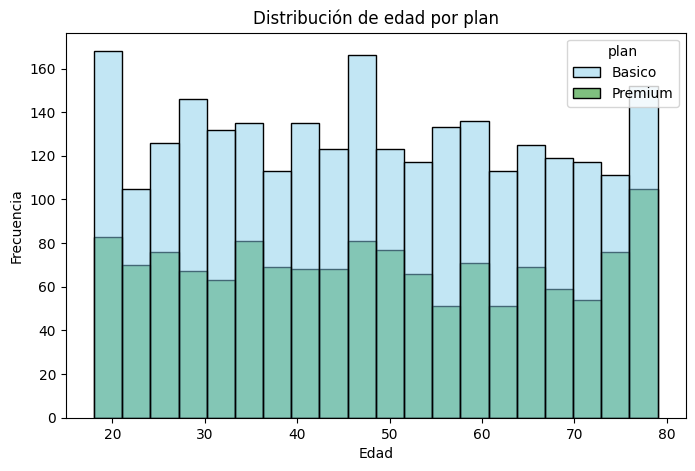

In [30]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue','green'],
    bins=20
)
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ...

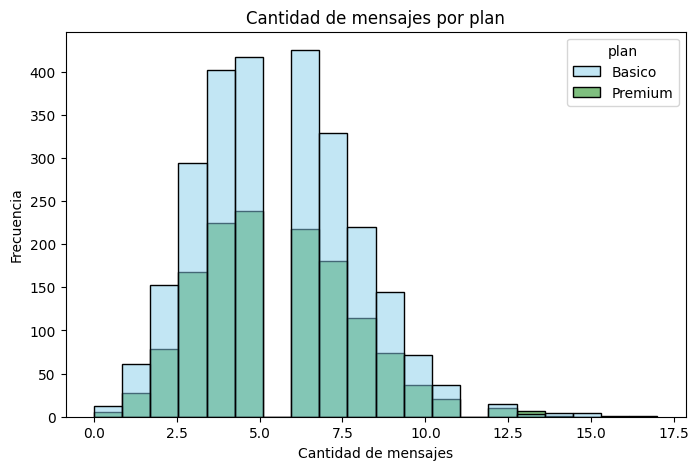

In [31]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue','green'],
    bins=20
)
plt.title('Cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- ....

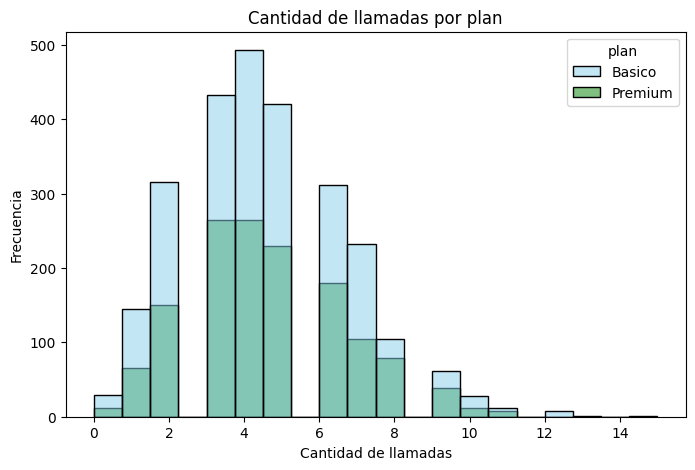

In [32]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue','green'],
    bins=20
)
plt.title('Cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ...

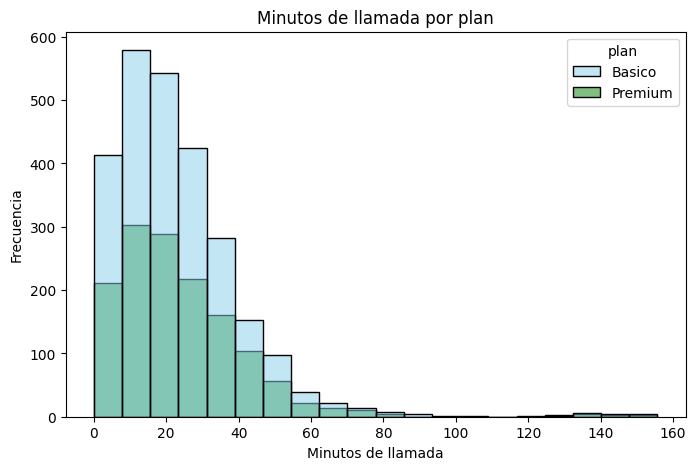

In [33]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue','green'],
    bins=20
)
plt.title('Minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

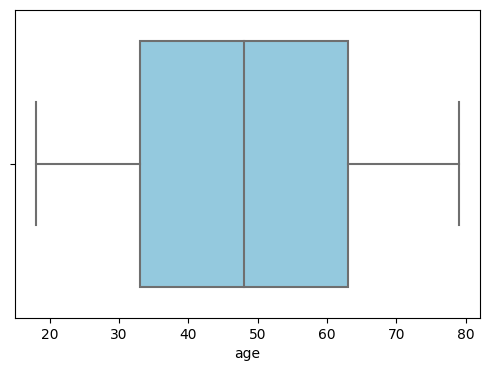

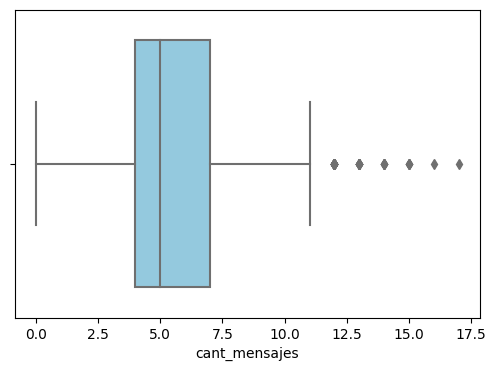

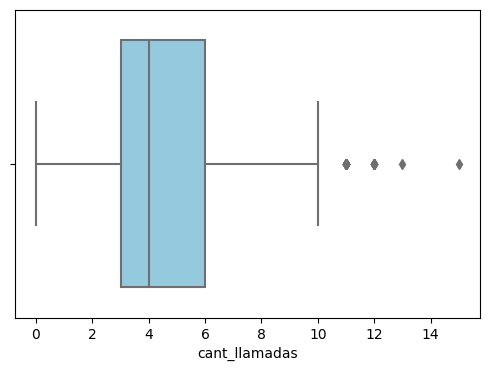

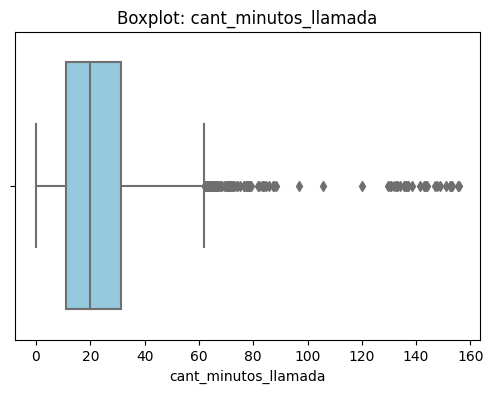

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x=user_profile[col],
        color='skyblue'
)
plt.title(f'Boxplot: {col}')
plt.xlabel(col)
plt.show()

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print(f'\n{col}')
print(f'Limite inferior: {limite_inferior:.2f}')
print(f'Limite superior: {limite_superior:.2f}')



cant_minutos_llamada
Limite inferior: -19.32
Limite superior: 61.86


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
def clasificar_uso(fila):
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
        
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'
    
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [38]:
# verificar cambios
user_profile[['user_id',
              'cant_mensajes',
              'cant_llamadas',
              'grupo_uso']].head()

,user_id,cant_mensajes,cant_llamadas,grupo_uso
0,10000,7.0,3.0,Uso medio
1,10001,5.0,10.0,Alto uso
2,10002,5.0,2.0,Uso medio
3,10003,11.0,3.0,Alto uso
4,10004,4.0,3.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
def grupo_edad(fila):
    if fila['age'] < 30:
        return 'Joven'
    elif fila['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad'] = user_profile.apply(grupo_edad, axis=1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

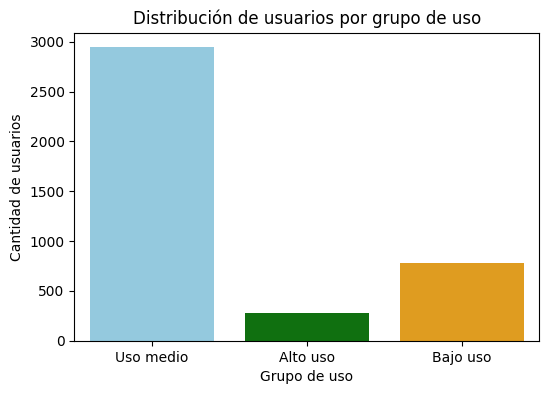

In [41]:
# Visualización de los segmentos por uso
plt.figure(figsize=(6,4))
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette=['skyblue', 'green', 'orange']
)
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

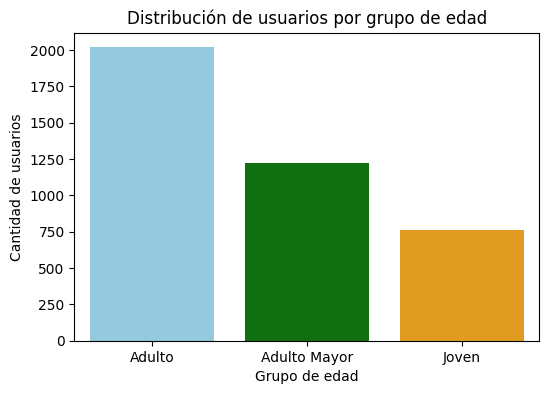

In [42]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette=['skyblue', 'green', 'orange']
)
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Se identificó un valor sentinel -999 en la columna age, utilizado para representar edades desconocidas. Este valor afectaba las estadísticas descriptivas de la edad y fue reemplazado por la mediana de las edades válidas.
  
- En la columna city se encontraron registros con el valor "?", equivalente a información faltante. Este valor se reemplazó por nulos (pd.NA) para facilitar su tratamiento posterior.

- En la columna reg_date se detectaron 40 registros con fecha en 2026, lo que representa aproximadamente el 1% de los usuarios (40 de 4000). Estas fechas estaban fuera del rango de análisis definido (hasta 2024) y fueron marcadas como nulas.

- Los nulos observados en duration y length no corresponden a errores de calidad. Se verificó que dependen de la variable type, ya que las llamadas registran duración pero no longitud del mensaje, mientras que los mensajes registran longitud pero no duración.


🔍 **Segmentos por Edad**

- Se clasificó a los usuarios en tres grupos: Joven (menores de 30 años), Adulto (entre 30 y 59 años) y Adulto Mayor (60 años o más).
  
- El segmento predominante corresponde a los Adultos, concentrando la mayor parte de la base de clientes.

- Los usuarios jóvenes representan un grupo relevante para estrategias digitales y servicios orientados al uso frecuente de comunicaciones.

- Los adultos mayores constituyen el segmento más pequeño y podrían presentar patrones de consumo más específicos y moderados.


📊 **Segmentos por Nivel de Uso**

- Se clasificaron los usuarios en Bajo uso, Uso medio y Alto uso según la cantidad de llamadas y mensajes registrados.

- Los usuarios de Alto uso realizan más llamadas y envían más mensajes que el promedio, generando un mayor consumo de los servicios ofrecidos.

- Los usuarios de Uso medio representan clientes con patrones de consumo estables y predecibles.

- Los usuarios de Bajo uso presentan poca actividad y podrían estar utilizando planes con beneficios superiores a sus necesidades reales.

➡️ Esto sugiere que ...

1. Existen perfiles claramente diferenciados de clientes dentro de ConnectaTel.
2. Los usuarios de alto consumo representan el segmento con mayor potencial de ingresos, especialmente si frecuentemente superan los límites incluidos en sus planes.
3. Los clientes de bajo consumo podrían beneficiarse de planes más económicos o simplificados.
4. La empresa tiene la oportunidad de adaptar mejor su oferta comercial a las necesidades reales de cada segmento.

💡 **Recomendaciones**

1. Diseñar ofertas diferenciadas para los segmentos identificados, especialmente para usuarios de alto uso y bajo uso.
2. Crear planes con mayores beneficios para clientes intensivos, reduciendo costos por excedentes y aumentando la fidelización.
3. Implementar campañas de migración de plan para usuarios cuyo consumo no coincide con las características de su plan actual.
4. Desarrollar estrategias específicas para clientes jóvenes, aprovechando su potencial de crecimiento y uso frecuente de los servicios.
5. Mantener un proceso de validación y limpieza de datos que permita identificar tempranamente valores sentinels, fechas inválidas y registros inconsistentes.
6. Monitorear periódicamente a los usuarios de consumo extremo para identificar oportunidades comerciales y prevenir posibles riesgos de abandono.

**Conclusión**

ConnectaTel cuenta con una base de clientes heterogénea, donde predominan los usuarios adultos y existen diferencias claras en los niveles de consumo. La segmentación realizada permite identificar grupos con necesidades distintas y abre oportunidades para optimizar la oferta de planes, mejorar la retención de clientes y maximizar los ingresos mediante estrategias comerciales más personalizadas.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`